Step 0 — Environment Setup

In [3]:
!pip install -q rasterio numpy matplotlib scipy seaborn pandas

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter
import rasterio
from rasterio.warp import reproject, Resampling
import os
import warnings
warnings.filterwarnings('ignore')

print("✓ Imports OK")

✓ Imports OK


Step 1 — Raster Loading and Inspection

In [5]:
VNL_PATH = 'VNL_cusco_2025.tif'
COB_PATH  = 'kernel_cobmovil2019_50m.tif'

def inspect_raster(path, label):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        meta = dict(
            CRS        = src.crs,
            shape      = (src.height, src.width),
            band_count = src.count,
            nodata     = src.nodata,
            dtype      = src.dtypes[0],
            bbox       = src.bounds,
            resolution = src.res,
        )
    sep = "=" * 56
    print(f"\n{sep}\n  {label}\n{sep}")
    for k, v in meta.items():
        print(f"  {k:<12}: {v}")
    return data, meta

vnl_raw, vnl_meta = inspect_raster(VNL_PATH, 'VNL Cusco 2025 (EPSG:4326)')
cob_raw, cob_meta = inspect_raster(COB_PATH, 'Kernel Cob. Móvil 2019 (EPSG:32719)')


  VNL Cusco 2025 (EPSG:4326)
  CRS         : EPSG:4326
  shape       : (1081, 961)
  band_count  : 1
  nodata      : None
  dtype       : float32
  bbox        : BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  resolution  : (0.0041666667, 0.0041666667)

  Kernel Cob. Móvil 2019 (EPSG:32719)
  CRS         : EPSG:32719
  shape       : (6116, 7754)
  band_count  : 1
  nodata      : -3.4028234663852886e+38
  dtype       : float32
  bbox        : BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  resolution  : (50.0, 50.0)


Step 2 — Reprojection and Grid Alignment

In [6]:
ALIGNED_PATH = 'kernel_aligned.tif'

with rasterio.open(VNL_PATH) as ref:
    ref_crs        = ref.crs
    ref_transform  = ref.transform
    ref_height     = ref.height
    ref_width      = ref.width
    vnl_arr        = ref.read(1).astype(np.float32)
    vnl_nodata_val = ref.nodata

if vnl_nodata_val is not None:
    vnl_arr[vnl_arr == vnl_nodata_val] = 0.0
vnl_arr = np.where(vnl_arr < 0, 0.0, vnl_arr)   # NL ≥ 0

with rasterio.open(COB_PATH) as src:
    cob_nodata_val = src.nodata if src.nodata is not None else 0.0
    destination    = np.zeros((ref_height, ref_width), dtype=np.float32)

    reproject(
        source        = rasterio.band(src, 1),
        destination   = destination,
        src_transform = src.transform,
        src_crs       = src.crs,
        dst_transform = ref_transform,
        dst_crs       = ref_crs,
        resampling    = Resampling.bilinear,
        src_nodata    = cob_nodata_val,
        dst_nodata    = 0.0,
    )

cob_aligned = np.where(destination < 0, 0.0, destination)

out_meta = {
    'driver': 'GTiff', 'dtype': 'float32', 'width': ref_width,
    'height': ref_height, 'count': 1, 'crs': ref_crs,
    'transform': ref_transform, 'nodata': 0.0,
}
with rasterio.open(ALIGNED_PATH, 'w', **out_meta) as dst:
    dst.write(cob_aligned, 1)

assert vnl_arr.shape == cob_aligned.shape, (
    f"Shapes no coinciden: VNL={vnl_arr.shape}  COB={cob_aligned.shape}"
)
print(f"✓ Shapes idénticos: {vnl_arr.shape}")
print(f"  VNL    — min={vnl_arr.min():.4f}  max={vnl_arr.max():.4f}  "
      f"non-zero={np.count_nonzero(vnl_arr):,}")
print(f"  CobMov — min={cob_aligned.min():.4f}  max={cob_aligned.max():.4f}  "
      f"non-zero={np.count_nonzero(cob_aligned):,}")
print(f"✓ Guardado: {ALIGNED_PATH}")

✓ Shapes idénticos: (1081, 961)
  VNL    — min=0.0000  max=1254.6145  non-zero=52,708
  CobMov — min=0.0000  max=0.0000  non-zero=102,616
✓ Guardado: kernel_aligned.tif


Step 3 — Robust Normalization

In [7]:
def normalize_p298(arr):
    """
    Normaliza [0,1] usando p2-p98 calculado sobre TODOS los
    píxeles del array (incluyendo ceros).
    """
    flat = arr.ravel()
    p2   = np.percentile(flat, 2)
    p98  = np.percentile(flat, 98)
    norm = (arr - p2) / (p98 - p2 + 1e-10)
    return np.clip(norm, 0.0, 1.0)

vnl_norm = normalize_p298(vnl_arr)
cob_norm = normalize_p298(cob_aligned)

print("Normalización p2–p98 (todos los píxeles incluyendo ceros):")
for name, raw, norm in [('VNL',    vnl_arr,    vnl_norm),
                         ('CobMov', cob_aligned, cob_norm)]:
    flat = raw.ravel()
    p2, p98 = np.percentile(flat, 2), np.percentile(flat, 98)
    print(f"  {name:<6}  p2={p2:.4f}  p98={p98:.4f}  "
          f"→ norm mean={norm.mean():.4f}  std={norm.std():.4f}")

Normalización p2–p98 (todos los píxeles incluyendo ceros):
  VNL     p2=0.0000  p98=0.6334  → norm mean=0.0391  std=0.1767
  CobMov  p2=0.0000  p98=0.0000  → norm mean=0.0389  std=0.1688


Step 4 — Map 1: VNL Nighttime Lights

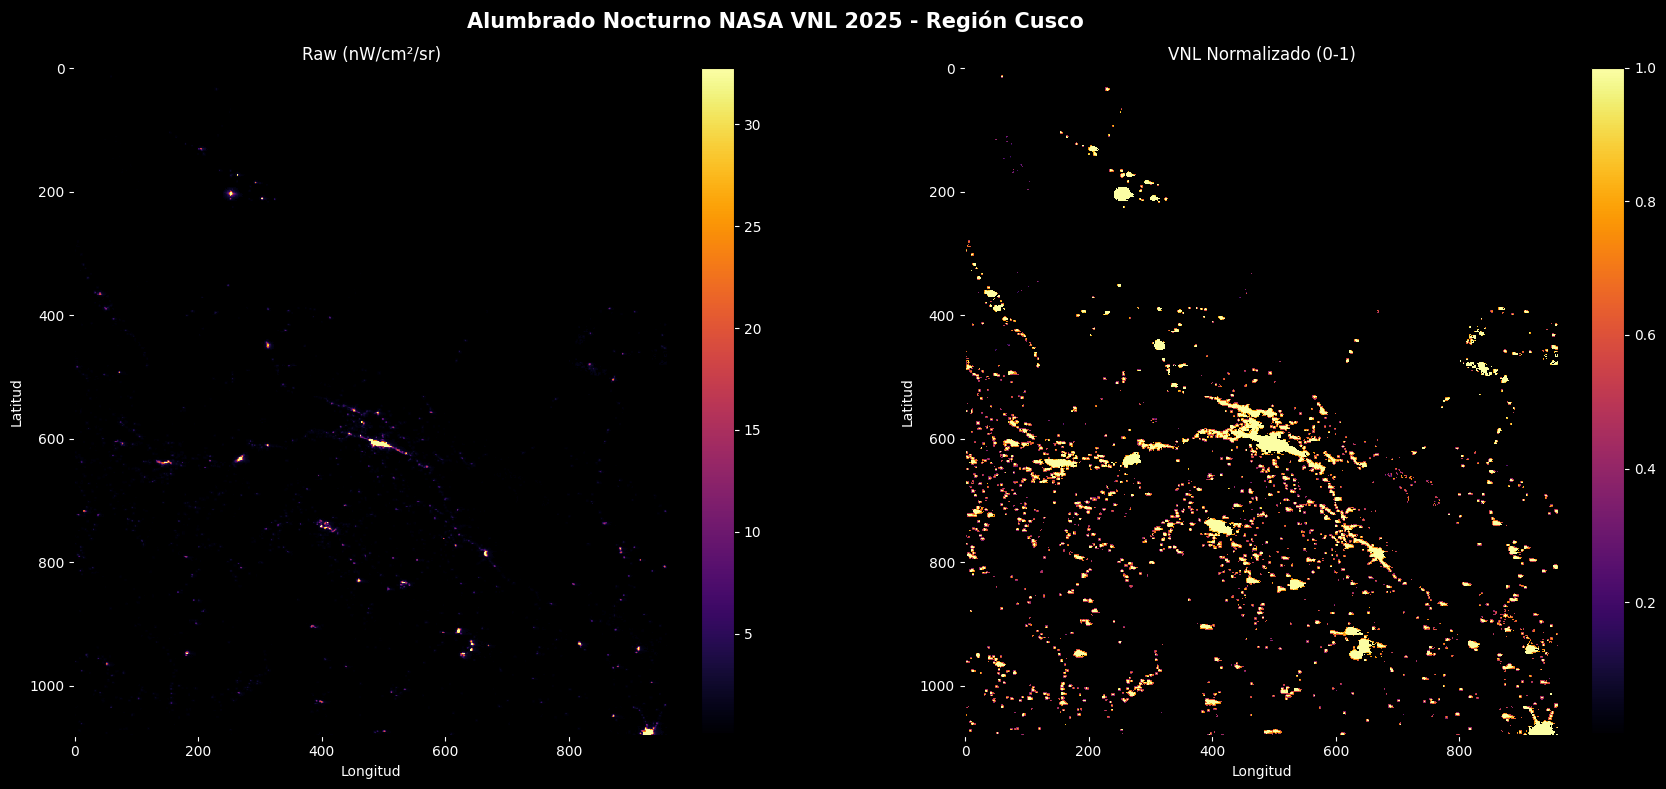


Observación:
Las zonas brillantes (colores amarillo-blanco) en ambos mapas indican alta emisión 
de luz artificial nocturna, concentrada principalmente en la ciudad de Cusco y el 
corredor Urubamba-Quillabamba (latitud ~-13°, longitud ~-72°). Estas zonas 
corresponden a centros urbanos consolidados con mayor actividad económica y poblacional.
La mayor parte del territorio regional permanece oscuro, especialmente las zonas 
andinas remotas y de selva alta, lo que refleja baja densidad poblacional y/o 
ausencia de infraestructura eléctrica. La normalización amplifica las señales débiles, 
revelando centros poblados menores invisibles en el mapa raw.

✓ Guardado: step4_vnl_raw_norm.png


In [39]:
def inferno_black(n=256):
    """inferno con primer bin negro (representa píxeles cero)."""
    colors = plt.cm.inferno(np.linspace(0, 1, n))
    colors[0] = [0, 0, 0, 1]
    return mcolors.LinearSegmentedColormap.from_list('inferno_black', colors)

CMAP_IB = inferno_black()

def make_masked(arr, threshold=1e-7):
    return np.ma.masked_where(arr < threshold, arr)

def dark_cmap(name):
    cm = plt.cm.get_cmap(name).copy()
    cm.set_bad('black')
    cm.set_under('black')
    return cm

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='black')
fig.suptitle('Alumbrado Nocturno NASA VNL 2025 - Región Cusco',
             color='white', fontsize=15, fontweight='bold')

ax = axes[0]
ax.set_facecolor('black')
vmax_raw = np.percentile(vnl_arr[vnl_arr > 0], 99) if np.any(vnl_arr > 0) else 1.0
cm_raw = CMAP_IB.copy();  cm_raw.set_bad('black');  cm_raw.set_under('black')
im0 = ax.imshow(make_masked(vnl_arr), cmap=cm_raw,
                vmin=1e-7, vmax=vmax_raw, interpolation='nearest')
ax.set_title('Raw (nW/cm²/sr)', color='white', fontsize=12)
ax.set_xlabel('Longitud', color='white', fontsize=10)
ax.set_ylabel('Latitud', color='white', fontsize=10)
ax.tick_params(colors='white')
cb0 = plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
cb0.ax.tick_params(colors='white')
plt.setp(cb0.ax.yaxis.get_ticklabels(), color='white')

ax = axes[1]
ax.set_facecolor('black')
cm_nrm = CMAP_IB.copy();  cm_nrm.set_bad('black');  cm_nrm.set_under('black')
im1 = ax.imshow(make_masked(vnl_norm), cmap=cm_nrm,
                vmin=1e-7, vmax=1.0, interpolation='nearest')
ax.set_title('VNL Normalizado (0-1)', color='white', fontsize=12)
ax.set_xlabel('Longitud', color='white', fontsize=10)
ax.set_ylabel('Latitud', color='white', fontsize=10)
ax.tick_params(colors='white')
cb1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cb1.ax.tick_params(colors='white')
plt.setp(cb1.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.savefig('step4_vnl_raw_norm.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("""
Observación:
Las zonas brillantes (colores amarillo-blanco) en ambos mapas indican alta emisión
de luz artificial nocturna, concentrada principalmente en la ciudad de Cusco y el
corredor Urubamba-Quillabamba (latitud ~-13°, longitud ~-72°). Estas zonas
corresponden a centros urbanos consolidados con mayor actividad económica y poblacional.
La mayor parte del territorio regional permanece oscuro, especialmente las zonas
andinas remotas y de selva alta, lo que refleja baja densidad poblacional y/o
ausencia de infraestructura eléctrica. La normalización amplifica las señales débiles,
revelando centros poblados menores invisibles en el mapa raw.
""")
print("✓ Guardado: step4_vnl_raw_norm.png")

Step 5 — Map 2: Digital Divide Index (IBD) and Exclusion Index (EDT)

IBD → min=-1.0000  max=1.0000  mean=0.0002
EDT → min=0.0000  max=1.0000  mean=0.9342


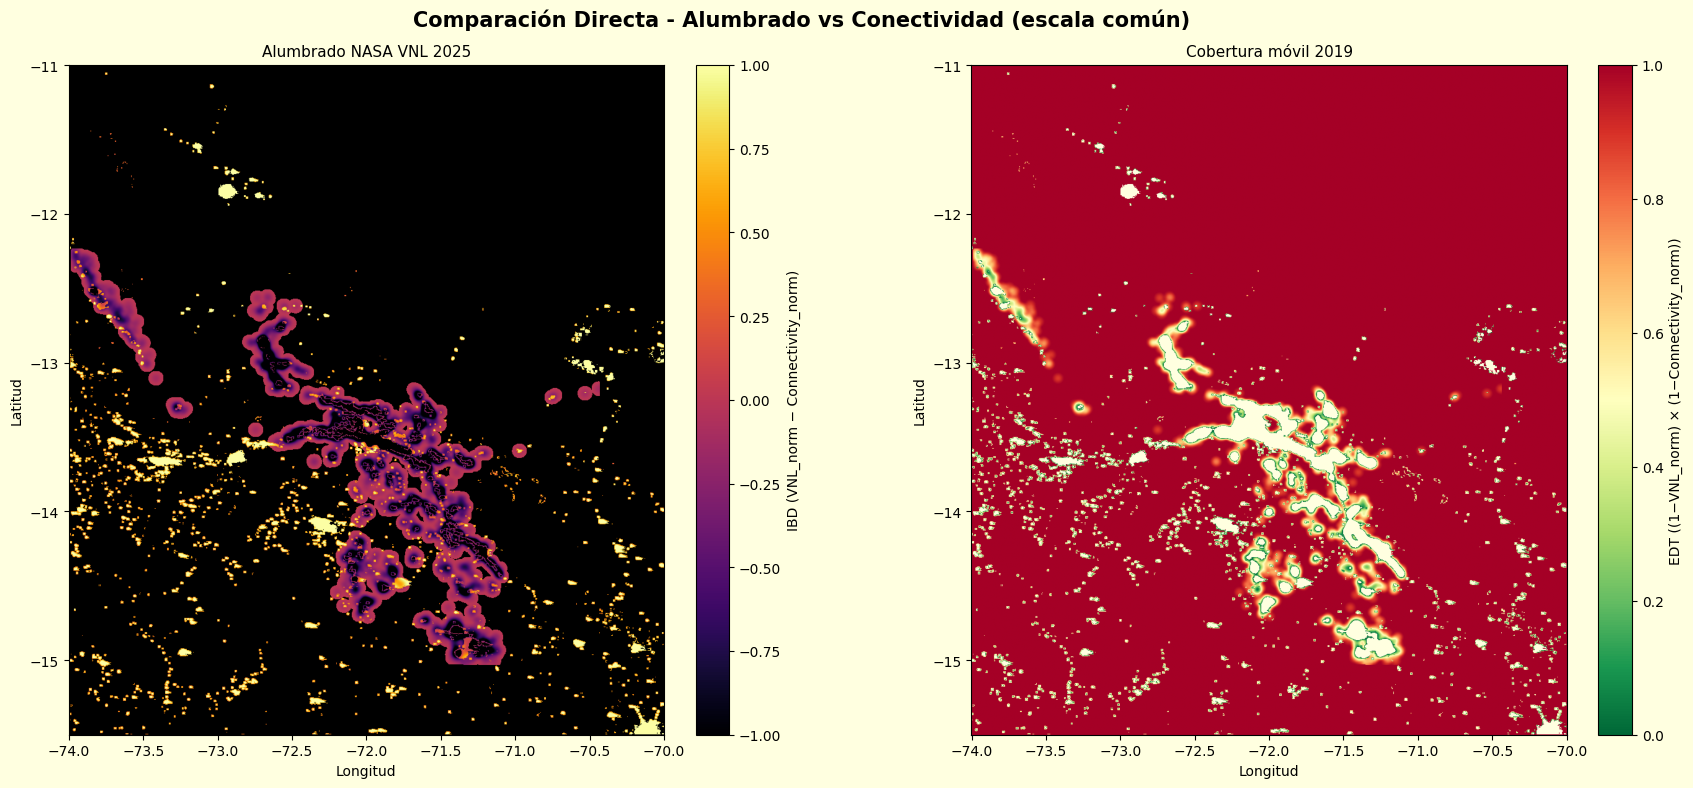


Interpretación IBD (Índice de Brecha Digital):
Las zonas rojas indican alta actividad nocturna con baja conectividad móvil — 
estas son las áreas con brecha digital activa donde hay población pero sin acceso 
a internet. Las zonas verdes indican áreas relativamente bien conectadas respecto 
a su nivel de actividad. En Cusco, la brecha es evidente en los corredores viales 
y centros poblados periurbanos.

Interpretación EDT (Exposición Digital Territorial):
Las zonas púrpuras oscuras identifican áreas con ni luz ni conectividad — 
máxima exclusión digital. Corresponden principalmente a zonas rurales remotas 
de la selva alta y Andes donde no llega ni electricidad ni señal móvil.



In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import rasterio

with rasterio.open("/content/VNL_cusco_2025.tif") as src:
    bounds_raw = src.bounds

extent = [bounds_raw.left, bounds_raw.right, bounds_raw.bottom, bounds_raw.top]

ibd = vnl_norm - cob_norm
edt = (1 - vnl_norm) * (1 - cob_norm)

print(f"IBD → min={ibd.min():.4f}  max={ibd.max():.4f}  mean={ibd.mean():.4f}")
print(f"EDT → min={edt.min():.4f}  max={edt.max():.4f}  mean={edt.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='lightyellow')
fig.suptitle('Comparación Directa - Alumbrado vs Conectividad (escala común)',
             color='black', fontsize=15, fontweight='bold')

ax = axes[0]
cm_ibd = plt.cm.get_cmap('inferno').copy()
cm_ibd.set_bad('black')
ax.set_facecolor('black')
im0 = ax.imshow(np.ma.masked_where(ibd == 0, ibd), cmap=cm_ibd,
                extent=extent, origin='upper', aspect='equal', vmin=-1, vmax=1)
ax.set_title('Alumbrado NASA VNL 2025',
             color='black', fontsize=11)
ax.set_xlabel('Longitud', color='black')
ax.set_ylabel('Latitud', color='black')
cb0 = plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
cb0.set_label('IBD (VNL_norm − Connectivity_norm)')

ax = axes[1]
ax.set_facecolor('lightyellow')
cm_edt = plt.cm.get_cmap('RdYlGn_r').copy()
cm_edt.set_bad('lightyellow')
ax.set_facecolor('lightyellow')
im1 = ax.imshow(np.ma.masked_where(edt == 0, edt), cmap=cm_edt,
                extent=extent, origin='upper', aspect='equal', vmin=0, vmax=1)
ax.set_title('Cobertura móvil 2019',
             color='black', fontsize=11)
ax.set_xlabel('Longitud', color='black')
ax.set_ylabel('Latitud', color='black')
cb1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cb1.set_label('EDT ((1−VNL_norm) × (1−Connectivity_norm))')

plt.tight_layout()
plt.savefig('step5_ibd_edt.png', dpi=150, bbox_inches='tight', facecolor='lightyellow')
plt.show()

print("""
Interpretación IBD (Índice de Brecha Digital):
Las zonas rojas indican alta actividad nocturna con baja conectividad móvil —
estas son las áreas con brecha digital activa donde hay población pero sin acceso
a internet. Las zonas verdes indican áreas relativamente bien conectadas respecto
a su nivel de actividad. En Cusco, la brecha es evidente en los corredores viales
y centros poblados periurbanos.

Interpretación EDT (Exposición Digital Territorial):
Las zonas púrpuras oscuras identifican áreas con ni luz ni conectividad —
máxima exclusión digital. Corresponden principalmente a zonas rurales remotas
de la selva alta y Andes donde no llega ni electricidad ni señal móvil.
""")

Step 6 — Map 3: Intervention Priority

Prioridad de Intervención
  t33 (P33) = 0.5265  →  baja / media
  t66 (P66) = 0.8944  →  media / alta
  0: Sin datos  —    998,961 px  (96.2%)
  1: Baja       —     13,161 px  (1.3%)
  2: Media      —     13,160 px  (1.3%)
  3: Alta       —     13,559 px  (1.3%)


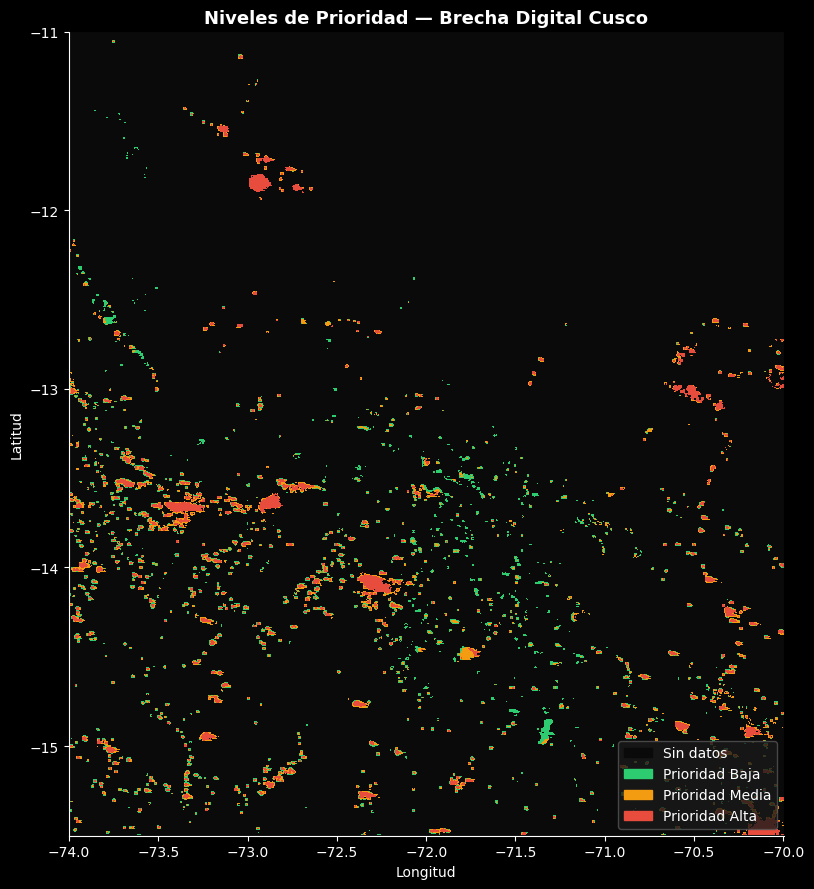

✓ Guardado: step6_prioridad.png


In [41]:
ibd_pos = ibd[ibd > 0]
t33, t66 = (np.percentile(ibd_pos, [33, 66]) if len(ibd_pos) > 0
            else (0.33, 0.66))

priority = np.zeros_like(ibd, dtype=np.uint8)
priority[ibd > 0]   = 1   # Baja
priority[ibd > t33] = 2   # Media
priority[ibd > t66] = 3   # Alta

print("Prioridad de Intervención")
print(f"  t33 (P33) = {t33:.4f}  →  baja / media")
print(f"  t66 (P66) = {t66:.4f}  →  media / alta")
for lvl, lbl in [(0,'Sin datos'),(1,'Baja'),(2,'Media'),(3,'Alta')]:
    pct = 100 * np.mean(priority == lvl)
    print(f"  {lvl}: {lbl:<10} — {np.sum(priority==lvl):>10,} px  ({pct:.1f}%)")

COLORS_PRIO  = ['#0a0a0a', '#2ecc71', '#f39c12', '#e74c3c']
CMAP_PRIO    = ListedColormap(COLORS_PRIO)
NORM_PRIO    = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], CMAP_PRIO.N)
PATCHES_PRIO = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(COLORS_PRIO,
                    ['Sin datos', 'Prioridad Baja', 'Prioridad Media', 'Prioridad Alta'])
]

fig, ax = plt.subplots(figsize=(11, 9), facecolor='black')
ax.set_facecolor('black')
ax.imshow(priority, cmap=CMAP_PRIO, norm=NORM_PRIO, interpolation='nearest')
ax.set_title('Niveles de Prioridad — Brecha Digital Cusco',
             color='white', fontsize=13, fontweight='bold')
extent = [bounds_raw.left, bounds_raw.right, bounds_raw.bottom, bounds_raw.top]
ax.imshow(priority, cmap=CMAP_PRIO, norm=NORM_PRIO,
          interpolation='nearest', extent=extent, origin='upper')
ax.set_xlabel('Longitud', color='white', fontsize=10)
ax.set_ylabel('Latitud', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.legend(handles=PATCHES_PRIO, loc='lower right',
          facecolor='#1a1a1a', edgecolor='#555', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.savefig('step6_prioridad.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("✓ Guardado: step6_prioridad.png")

Step 7 — Map 4: Social Exclusion Risk

Riesgo Gaussiano
  min=-0.9202  max=1.0000
  mean=0.0002  std=0.1298
  Percentil 75: 0.0071
  Percentil 90: 0.0724


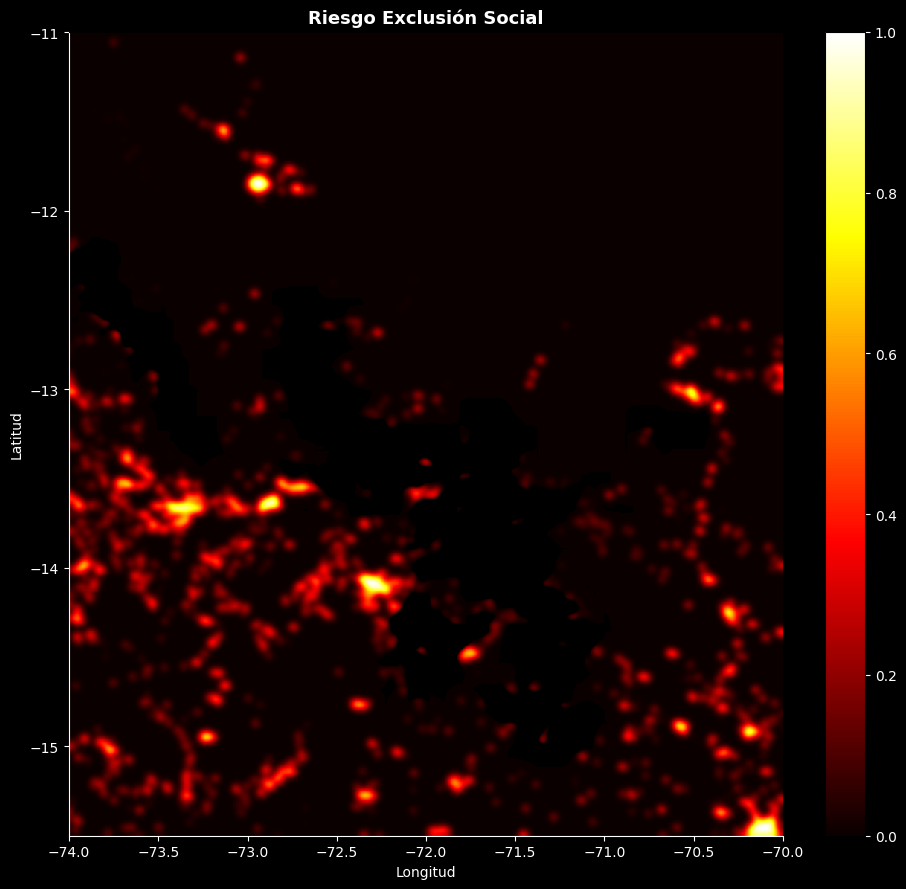

✓ Guardado: step7_riesgo_gaussiano.png


In [46]:
SIGMA = 5
risk_gauss = gaussian_filter(ibd.astype(np.float64), sigma=SIGMA)
_rg_max = risk_gauss.max()
if _rg_max > 0:
    risk_gauss = risk_gauss / _rg_max
risk_gauss = risk_gauss.astype(np.float32)

p75 = np.percentile(risk_gauss, 75)
p90 = np.percentile(risk_gauss, 90)
print(f"Riesgo Gaussiano")
print(f"  min={risk_gauss.min():.4f}  max={risk_gauss.max():.4f}")
print(f"  mean={risk_gauss.mean():.4f}  std={risk_gauss.std():.4f}")
print(f"  Percentil 75: {p75:.4f}")
print(f"  Percentil 90: {p90:.4f}")

extent = [bounds_raw.left, bounds_raw.right, bounds_raw.bottom, bounds_raw.top]

fig, ax = plt.subplots(figsize=(11, 9), facecolor='black')
ax.set_facecolor('black')
cm = dark_cmap('hot')
im = ax.imshow(risk_gauss, cmap=cm,
               extent=extent, origin='upper',
               vmin=0, vmax=1.0, interpolation='nearest')
ax.set_title(f'Riesgo Exclusión Social',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud', color='white', fontsize=10)
ax.set_ylabel('Latitud', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
plt.tight_layout()
plt.savefig('step7_riesgo_gaussiano.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("✓ Guardado: step7_riesgo_gaussiano.png")

Step 8 — Territorial Classification

Clasificación 2x2 — umbral VNL=0.15, Connectivity=0.15:
  Clase 0: Sin datos                     0 px  (0.0%)  ~0 km²
  Clase 1: Urban Connected          17,522 px  (1.7%)  ~8,761 km²
  Clase 2: Urban Divide             35,176 px  (3.4%)  ~17,588 km²
  Clase 3: Rural Connected          42,424 px  (4.1%)  ~21,212 km²
  Clase 4: Critical Divide         943,719 px  (90.8%)  ~471,860 km²

✓ Guardado: clasificacion_brecha.tif


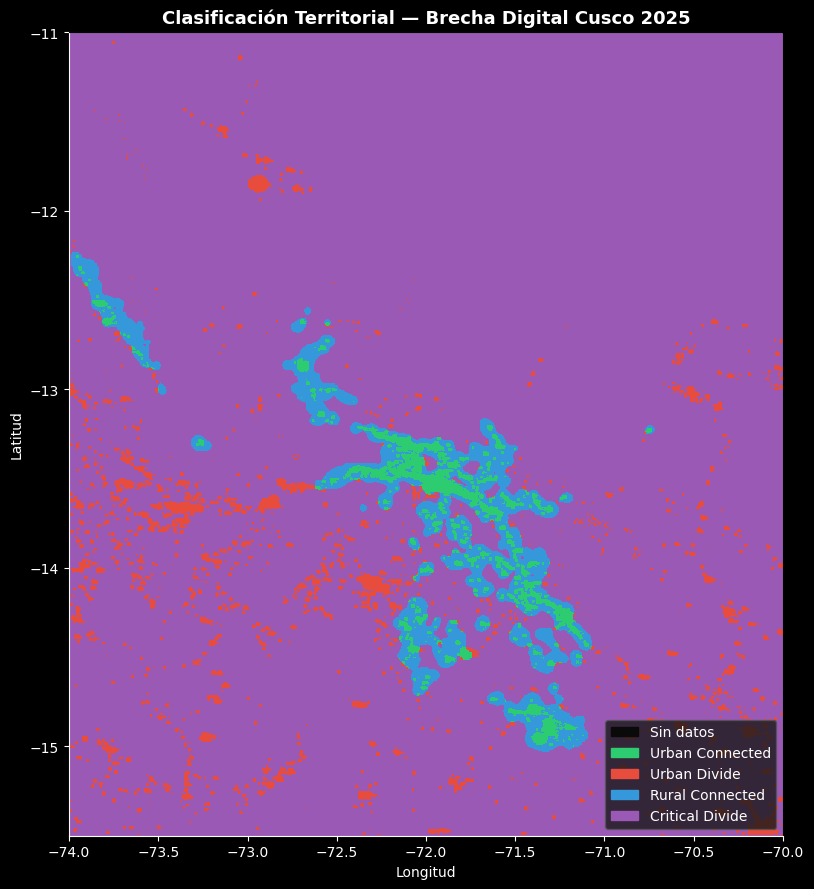

✓ Guardado: step8_clasificacion.png


In [47]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

THR = 0.15

# Clasificación 2x2
clasif = np.zeros_like(vnl_norm, dtype=np.uint8)
clasif[(vnl_norm >= THR) & (cob_norm >= THR)] = 1  # Urban Connected
clasif[(vnl_norm >= THR) & (cob_norm <  THR)] = 2  # Urban Divide
clasif[(vnl_norm <  THR) & (cob_norm >= THR)] = 3  # Rural Connected
clasif[(vnl_norm <  THR) & (cob_norm <  THR)] = 4  # Critical Divide

CLASS_LABELS = {
    0: 'Sin datos',
    1: 'Urban Connected',
    2: 'Urban Divide',
    3: 'Rural Connected',
    4: 'Critical Divide',
}

# Área aproximada por píxel en km²
pixel_area_km2 = 0.5  # aproximado para esta resolución

print("Clasificación 2x2 — umbral VNL=0.15, Connectivity=0.15:")
for c in range(5):
    n = int(np.sum(clasif == c))
    pct = 100 * n / clasif.size
    area = n * pixel_area_km2
    print(f"  Clase {c}: {CLASS_LABELS[c]:<20} {n:>10,} px  ({pct:.1f}%)  ~{area:,.0f} km²")

# Guardar GeoTIFF
with rasterio.open("/content/VNL_cusco_2025.tif") as ref:
    meta = ref.meta.copy()
    bounds_raw = ref.bounds

meta.update(dtype='uint8', count=1, nodata=0, compress='lzw')
with rasterio.open('clasificacion_brecha.tif', 'w', **meta) as dst:
    dst.write(clasif, 1)
print("\n✓ Guardado: clasificacion_brecha.tif")

# Graficar
COLORS_CLS  = ['#0a0a0a', '#2ecc71', '#e74c3c', '#3498db', '#9b59b6']
CMAP_CLS    = ListedColormap(COLORS_CLS)
NORM_CLS    = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], CMAP_CLS.N)
PATCHES_CLS = [
    mpatches.Patch(color=c, label=f"{CLASS_LABELS[i]}")
    for i, c in enumerate(COLORS_CLS)
]

extent = [bounds_raw.left, bounds_raw.right, bounds_raw.bottom, bounds_raw.top]

fig, ax = plt.subplots(figsize=(11, 9), facecolor='black')
ax.set_facecolor('black')
ax.imshow(clasif, cmap=CMAP_CLS, norm=NORM_CLS,
          extent=extent, origin='upper', interpolation='nearest')
ax.set_title('Clasificación Territorial — Brecha Digital Cusco 2025',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud', color='white', fontsize=10)
ax.set_ylabel('Latitud', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.legend(handles=PATCHES_CLS, loc='lower right',
          facecolor='#1a1a1a', edgecolor='#555', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.savefig('step8_clasificacion.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("✓ Guardado: step8_clasificacion.png")

Step 9 — Statistical Summary

Píxeles válidos (ambas capas > 0): 19,672

Estadísticas descriptivas:
         VNL_norm  conn_norm.tif         IBD      Riesgo
count  19672.0000     19672.0000  19672.0000  19672.0000
mean       0.8171         0.7593      0.0578     -0.2706
std        0.2123         0.3462      0.3485      0.2416
min        0.2735         0.0000     -0.6979     -0.8437
25%        0.6216         0.5121     -0.1257     -0.4501
50%        0.9430         1.0000      0.0000     -0.2944
75%        1.0000         1.0000      0.2326     -0.1094
max        1.0000         1.0000      1.0000      0.6408

Correlación VNL vs CobMov (19,672 píxeles):
  Pearson   r = +0.2957   p = 0.000e+00
  Spearman  r = +0.3056   p = 0.000e+00

Test de Welch — IBD Q75+ vs IBD Q25-:
  n_alta=4,918  n_baja=4,918
  t = 253.9658   p = 0.000e+00
  *** Significativo (p<0.05)


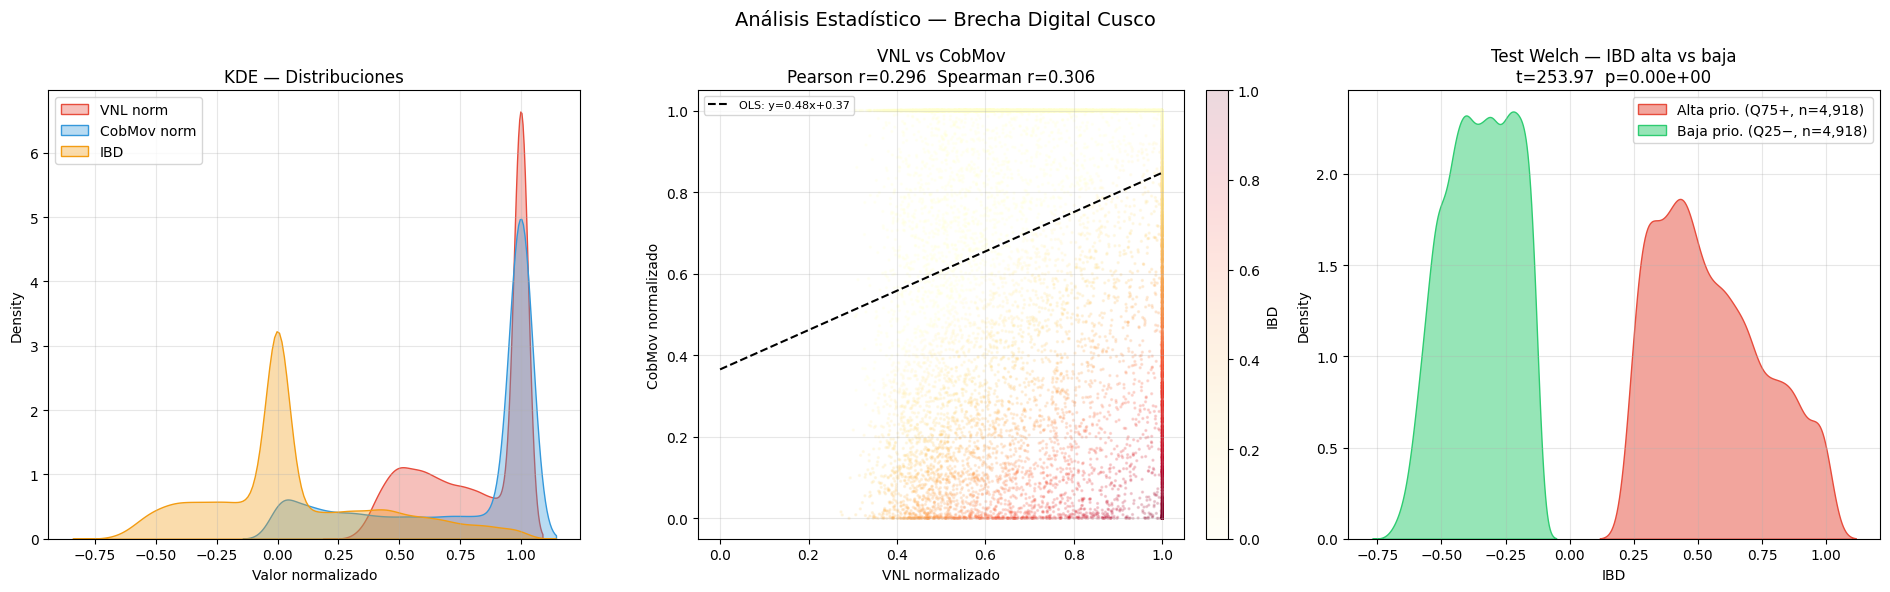

✓ Guardado: step9_estadisticas.png


In [56]:
mask_valid = (vnl_norm > 1e-7) & (cob_norm > 1e-7)
vnl_v = vnl_norm[mask_valid].ravel()
cob_v = cob_norm[mask_valid].ravel()
ibd_v = ibd[mask_valid].ravel()
rg_v  = risk_gauss[mask_valid].ravel()

print(f"Píxeles válidos (ambas capas > 0): {len(vnl_v):,}")

df_stats = pd.DataFrame({'VNL_norm': vnl_v, 'conn_norm.tif': cob_v,
                          'IBD': ibd_v, 'Riesgo': rg_v})
print("\nEstadísticas descriptivas:")
print(df_stats.describe().round(4).to_string())

r_pe, p_pe = stats.pearsonr(vnl_v,  cob_v)
r_sp, p_sp = stats.spearmanr(vnl_v, cob_v)
print(f"\nCorrelación VNL vs CobMov ({len(vnl_v):,} píxeles):")
print(f"  Pearson   r = {r_pe:+.4f}   p = {p_pe:.3e}")
print(f"  Spearman  r = {r_sp:+.4f}   p = {p_sp:.3e}")

q25_v, q75_v = np.percentile(ibd_v, [25, 75])
ibd_hi = ibd_v[ibd_v >= q75_v]
ibd_lo = ibd_v[ibd_v <= q25_v]
t_w, p_w = stats.ttest_ind(ibd_hi, ibd_lo, equal_var=False)
print(f"\nTest de Welch — IBD Q75+ vs IBD Q25-:")
print(f"  n_alta={len(ibd_hi):,}  n_baja={len(ibd_lo):,}")
print(f"  t = {t_w:.4f}   p = {p_w:.3e}")
print(f"  {'*** Significativo (p<0.05)' if p_w < 0.05 else 'Sin diferencia significativa'}")

N_SAMPLE = min(60_000, len(vnl_v))
rng = np.random.default_rng(42)
idx = rng.choice(len(vnl_v), N_SAMPLE, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Análisis Estadístico — Brecha Digital Cusco', fontsize=14)

# KDE distribuciones
ax = axes[0]
for arr, label, color in [
    (vnl_v[idx],  'VNL norm',    '#e74c3c'),
    (cob_v[idx],  'CobMov norm', '#3498db'),
    (ibd_v[idx],  'IBD',         '#f39c12'),
]:
    sns.kdeplot(arr, ax=ax, label=label, fill=True, alpha=0.35, color=color)
ax.set_title('KDE — Distribuciones')
ax.set_xlabel('Valor normalizado');  ax.legend();  ax.grid(True, alpha=0.3)

# Scatter VNL vs CobMov coloreado por IBD
ax = axes[1]
sc = ax.scatter(vnl_v[idx], cob_v[idx], c=ibd_v[idx],
                cmap='YlOrRd', alpha=0.15, s=2, vmin=0, vmax=1)
m, b  = np.polyfit(vnl_v[idx], cob_v[idx], 1)
x_l   = np.linspace(0, 1, 200)
ax.plot(x_l, np.clip(m*x_l + b, 0, 1), 'k--', lw=1.5,
        label=f'OLS: y={m:.2f}x+{b:.2f}')
ax.set_xlabel('VNL normalizado');  ax.set_ylabel('CobMov normalizado')
ax.set_title(f'VNL vs CobMov\nPearson r={r_pe:.3f}  Spearman r={r_sp:.3f}')
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='IBD', fraction=0.046, pad=0.04)

# KDE Welch alta vs baja prioridad
ax = axes[2]
sns.kdeplot(ibd_hi, ax=ax, fill=True, alpha=0.5, color='#e74c3c',
            label=f'Alta prio. (Q75+, n={len(ibd_hi):,})')
sns.kdeplot(ibd_lo, ax=ax, fill=True, alpha=0.5, color='#2ecc71',
            label=f'Baja prio. (Q25−, n={len(ibd_lo):,})')
ax.set_title(f'Test Welch — IBD alta vs baja\nt={t_w:.2f}  p={p_w:.2e}')
ax.set_xlabel('IBD');  ax.legend();  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step9_estadisticas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: step9_estadisticas.png")

Step 10 — Export Deliverables

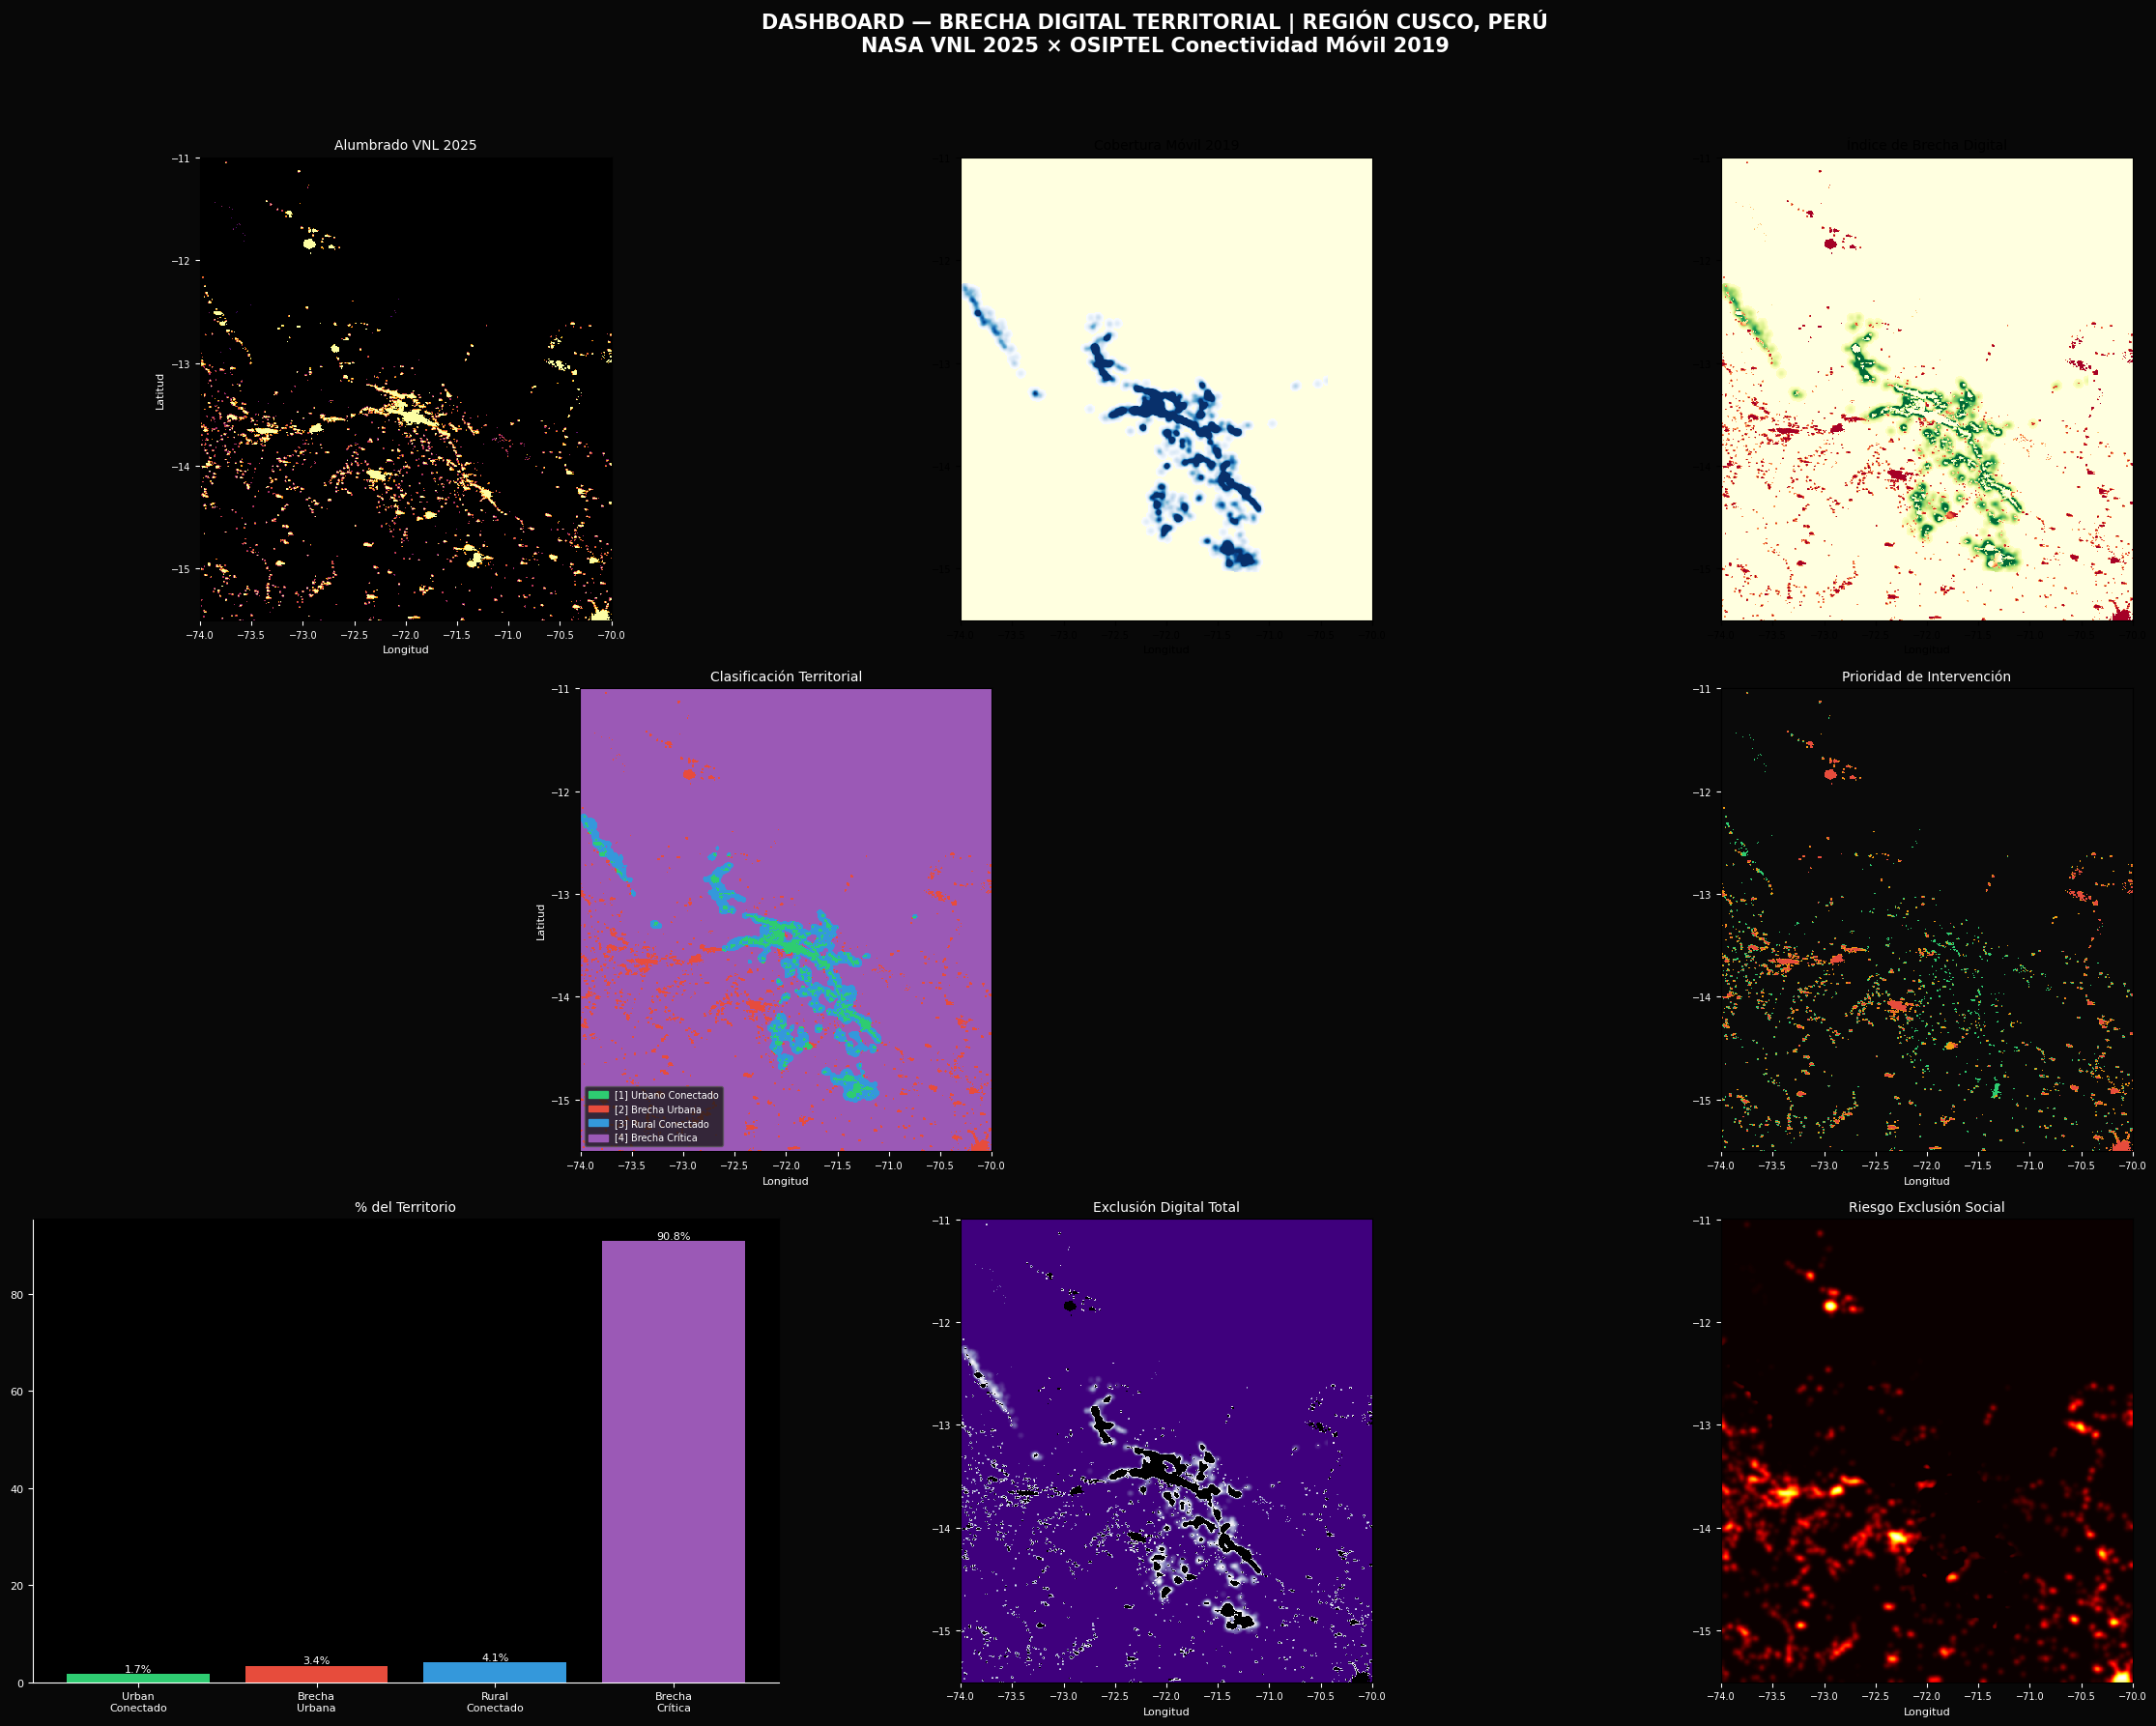

✓ Dashboard guardado!


In [48]:
# Calcular % por clase para el gráfico de barras
class_names = ['Urban\nConectado', 'Brecha\nUrbana', 'Rural\nConectado', 'Brecha\nCrítica']
class_pcts = [100 * np.mean(clasif == i) for i in range(1, 5)]
class_colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

fig = plt.figure(figsize=(24, 18), facecolor='#080808')
fig.suptitle('DASHBOARD — BRECHA DIGITAL TERRITORIAL | REGIÓN CUSCO, PERÚ\nNASA VNL 2025 × OSIPTEL Conectividad Móvil 2019',
             color='white', fontsize=15, fontweight='bold', y=0.99)

# Panel 1 - VNL normalizado
ax1 = fig.add_subplot(3, 3, 1)
ax1.set_facecolor('black')
cm1 = CMAP_IB.copy(); cm1.set_bad('black')
ax1.imshow(make_masked(vnl_norm), cmap=cm1, vmin=1e-7, vmax=1.0,
           extent=extent, origin='upper', interpolation='nearest')
ax1.set_title('Alumbrado VNL 2025', color='white', fontsize=10)
ax1.set_xlabel('Longitud', color='white', fontsize=8)
ax1.set_ylabel('Latitud', color='white', fontsize=8)
ax1.tick_params(colors='white', labelsize=7)

# Panel 2 - Cobertura Móvil
ax2 = fig.add_subplot(3, 3, 2)
ax2.set_facecolor('lightyellow')
cm2 = plt.cm.get_cmap('Blues').copy(); cm2.set_bad('lightyellow')
ax2.imshow(np.ma.masked_where(cob_norm <= 0, cob_norm), cmap=cm2, vmin=0, vmax=1,
           extent=extent, origin='upper', interpolation='nearest')
ax2.set_title('Cobertura Móvil 2019', color='black', fontsize=10)
ax2.set_xlabel('Longitud', color='black', fontsize=8)
ax2.tick_params(colors='black', labelsize=7)

# Panel 3 - IBD
ax3 = fig.add_subplot(3, 3, 3)
ax3.set_facecolor('lightyellow')
cm3 = plt.cm.get_cmap('RdYlGn_r').copy(); cm3.set_bad('lightyellow')
ax3.imshow(np.ma.masked_where(ibd == 0, ibd), cmap=cm3, vmin=-1, vmax=1,
           extent=extent, origin='upper', interpolation='nearest')
ax3.set_title('Índice de Brecha Digital', color='black', fontsize=10)
ax3.set_xlabel('Longitud', color='black', fontsize=8)
ax3.tick_params(colors='black', labelsize=7)

# Panel 4 - Clasificación (ancho doble)
ax4 = fig.add_subplot(3, 3, (4, 5))
ax4.set_facecolor('black')
ax4.imshow(clasif, cmap=CMAP_CLS, norm=NORM_CLS,
           extent=extent, origin='upper', interpolation='nearest')
ax4.set_title('Clasificación Territorial', color='white', fontsize=10)
ax4.set_xlabel('Longitud', color='white', fontsize=8)
ax4.set_ylabel('Latitud', color='white', fontsize=8)
ax4.tick_params(colors='white', labelsize=7)
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(['#2ecc71','#e74c3c','#3498db','#9b59b6'],
                           ['[1] Urbano Conectado','[2] Brecha Urbana','[3] Rural Conectado','[4] Brecha Crítica'])]
ax4.legend(handles=patches, loc='lower left', facecolor='#1a1a1a',
           edgecolor='#555', labelcolor='white', fontsize=7)

# Panel 5 - Prioridad
ax5 = fig.add_subplot(3, 3, 6)
ax5.set_facecolor('black')
ax5.imshow(priority, cmap=CMAP_PRIO, norm=NORM_PRIO,
           extent=extent, origin='upper', interpolation='nearest')
ax5.set_title('Prioridad de Intervención', color='white', fontsize=10)
ax5.set_xlabel('Longitud', color='white', fontsize=8)
ax5.tick_params(colors='white', labelsize=7)

# Panel 6 - Barras % territorio
ax6 = fig.add_subplot(3, 3, 7)
ax6.set_facecolor('black')
bars = ax6.bar(class_names, class_pcts, color=class_colors)
for bar, pct in zip(bars, class_pcts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', color='white', fontsize=8)
ax6.set_title('% del Territorio', color='white', fontsize=10)
ax6.tick_params(colors='white', labelsize=8)
ax6.set_facecolor('black')
ax6.spines['bottom'].set_color('white')
ax6.spines['left'].set_color('white')
ax6.yaxis.label.set_color('white')

# Panel 7 - EDT
ax7 = fig.add_subplot(3, 3, 8)
ax7.set_facecolor('black')
cm7 = plt.cm.get_cmap('Purples').copy(); cm7.set_bad('black')
ax7.imshow(np.ma.masked_where(edt == 0, edt), cmap=cm7, vmin=0, vmax=1,
           extent=extent, origin='upper', interpolation='nearest')
ax7.set_title('Exclusión Digital Total', color='white', fontsize=10)
ax7.set_xlabel('Longitud', color='white', fontsize=8)
ax7.tick_params(colors='white', labelsize=7)

# Panel 8 - Riesgo Gaussiano
ax8 = fig.add_subplot(3, 3, 9)
ax8.set_facecolor('black')
cm8 = plt.cm.get_cmap('hot').copy(); cm8.set_bad('black')
ax8.imshow(risk_gauss, cmap=cm8, vmin=0, vmax=1,
           extent=extent, origin='upper', interpolation='nearest')
ax8.set_title('Riesgo Exclusión Social', color='white', fontsize=10)
ax8.set_xlabel('Longitud', color='white', fontsize=8)
ax8.tick_params(colors='white', labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('dashboard_brecha_digital.png', dpi=150, bbox_inches='tight', facecolor='#080808')
plt.show()
print("✓ Dashboard guardado!")

In [61]:
from google.colab import files

files.download('vnl_norm.tif')
files.download('conn_norm.tif')
files.download('ibd_brecha_digital.tif')
files.download('clasificacion_brecha.tif')
files.download('dashboard_brecha_digital.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>